# Load packages

In [1]:
import os
import torch
import pandas as pd
import scanpy as sc
import warnings
from muon import prot as pt
import sys
sys.path.append("./model/")
from train import train_SMAHD
from utils import set_seed
set_seed(2025)
warnings.filterwarnings('ignore')
# Environment configuration. SpatialGlue pacakge can be implemented with either CPU or GPU. GPU acceleration is highly recommend for imporoved efficiency.
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# the location of R, which is required for the 'mclust' algorithm. Please replace the path below with local R installation path
os.environ['R_HOME'] = "/usr/lib/R/"

# Load data and construct spatial neighbour graph

In [2]:
path="/home/dwang/SMAHD/data/Human_tonsil/slice1/"
adata1 = sc.read_h5ad(path + 'adata_rna.h5ad')
adata2 = sc.read_h5ad(path + 'adata_adt.h5ad')

adata1.var_names_make_unique()
adata2.var_names_make_unique()
from model.utils import Cal_Spatial_Net
Cal_Spatial_Net(adata1, model="KNN", n_neighbors=5)
Cal_Spatial_Net(adata2, model="KNN", n_neighbors=5)

The graph contains 21630 edges, 4326 cells.
5.0000 neighbors per cell on average.
The graph contains 21630 edges, 4326 cells.
5.0000 neighbors per cell on average.


In [3]:
adata1.obs['anno']=adata1.obs['final_annot'].map({"tonsillar parenchyma":"tonsillar parenchyma"  ,  
"lymphoid follicle" :"lymphoid follicle"  ,             
"connective & epithelial tissue" :"connective & epithelial tissue"  ,
"connective and epithelial tissue" :"connective & epithelial tissue" ,   
"germinal center":"germinal center" ,                      
"germinal Center":"germinal center" })

# Data pre-processing

In [4]:
# RNA
sc.pp.filter_genes(adata1, min_cells=10)
sc.pp.highly_variable_genes(adata1, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata1, target_sum=1e4)
sc.pp.log1p(adata1)
sc.pp.scale(adata1)
sc.pp.pca(adata1,n_comps=30)
# Protein
adata2.X=adata2.X.astype('float32')
adata2 = adata2[adata1.obs_names].copy()
pt.pp.clr(adata2)
sc.pp.scale(adata2)
sc.pp.pca(adata2,n_comps=20)

# Model training and Clustering

In [5]:
adata_list=[adata1,adata2]
x = [torch.FloatTensor(adata.obsm['X_pca']) for adata in adata_list]
edge =torch.LongTensor(adata1.uns["edgeList"])

adata1.obsm["SMAHD"]=train_SMAHD(features=x,
            edge=edge,
            weights=[1,1],
            emb_dim=64, 
            train_batch_size=10000,
            infer_batch_size=1000,      
            n_epochs=100,
            lr=0.001,
            weight_decay=1e-6,
            train_device = device,
            infer_device=torch.device('cpu'))
from utils import clustering
from sklearn.metrics import adjusted_rand_score

tool = 'mclust'  # mclust, leiden, and louvain
clustering(adata1, key='SMAHD', add_key='SMAHD', n_clusters=6, method=tool, use_pca=True)
ari = adjusted_rand_score(adata1.obs['anno'], adata1.obs["SMAHD"])
print(ari)

Computing METIS partitioning...
Done!
Epoch [100/100]: 100%|██████████| 100/100 [00:18<00:00,  5.30it/s, loss=14.6]
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
0.1736205418408722


In [6]:
# RNA
adata_list=[adata1]
x = [torch.FloatTensor(adata.obsm['X_pca']) for adata in adata_list]
edge =torch.LongTensor(adata1.uns["edgeList"])

adata1.obsm["RNA"]=train_SMAHD(features=x,
            edge=edge,
            weights=[1,1],
            emb_dim=64, 
            train_batch_size=10000,
            infer_batch_size=1000,      
            n_epochs=100,
            lr=0.001,
            weight_decay=1e-6,
            train_device = device,
            infer_device=torch.device('cpu'))
from utils import clustering
from sklearn.metrics import adjusted_rand_score

tool = 'mclust'  # mclust, leiden, and louvain
clustering(adata1, key='RNA', add_key='RNA', n_clusters=6, method=tool, use_pca=True)
ari = adjusted_rand_score(adata1.obs['anno'], adata1.obs["RNA"])
print(ari)

Computing METIS partitioning...
Done!
Epoch [100/100]: 100%|██████████| 100/100 [00:17<00:00,  5.65it/s, loss=14]


fitting ...
  |======================================================================| 100%
0.1115465302689484


In [8]:
# ADT
adata_list=[adata2]
x = [torch.FloatTensor(adata.obsm['X_pca']) for adata in adata_list]
edge =torch.LongTensor(adata1.uns["edgeList"])

adata2.obsm["ADT"]=train_SMAHD(features=x,
            edge=edge,
            weights=[1,1],
            emb_dim=64, 
            train_batch_size=10000,
            infer_batch_size=1000,      
            n_epochs=100,
            lr=0.001,
            weight_decay=1e-6,
            train_device = device,
            infer_device=torch.device('cpu'))
from utils import clustering
from sklearn.metrics import adjusted_rand_score
tool = 'mclust'  # mclust, leiden, and louvain
clustering(adata2, key='ADT', add_key='ADT', n_clusters=6, method=tool, use_pca=True)
ari = adjusted_rand_score(adata1.obs['anno'], adata2.obs["ADT"])
print(ari)

Computing METIS partitioning...
Done!
Epoch [100/100]: 100%|██████████| 100/100 [00:18<00:00,  5.37it/s, loss=1.11]


fitting ...
  |======================================================================| 100%
0.09855949021920468


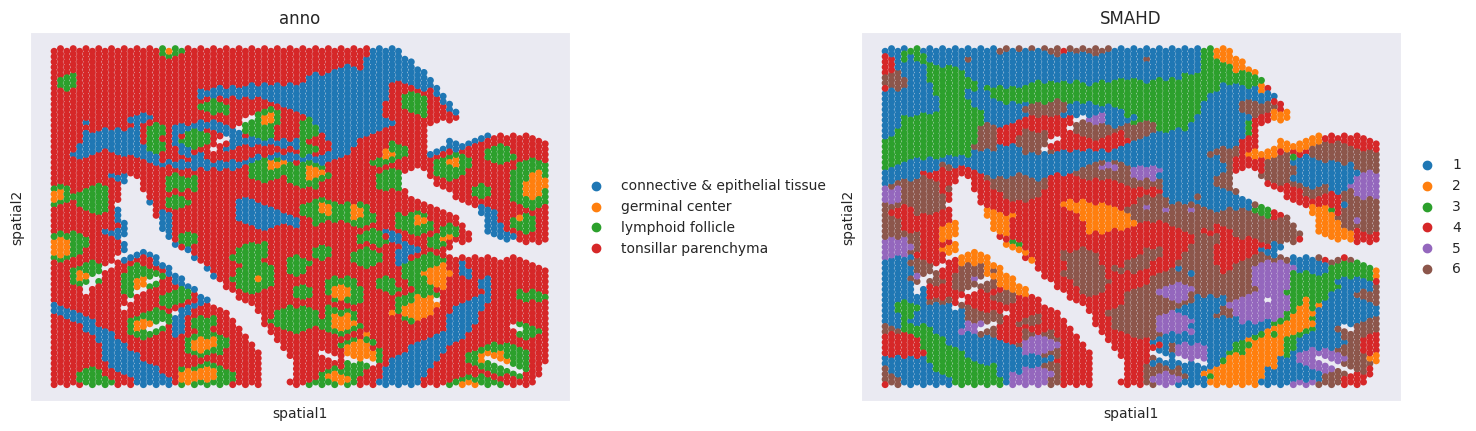

In [13]:
sc.pl.embedding(adata1,basis="spatial",color=["anno",'SMAHD'],s=100,wspace=0.4)